<a href="https://colab.research.google.com/github/felipebatalini/AIHC5020/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1: Loading Data from Google Cloud Storage

In [1]:
import pandas as pd
from google.cloud import storage
from google.auth.credentials import AnonymousCredentials

# 1. Initialize GCS Client with Anonymous Credentials
storage_client = storage.Client(credentials=AnonymousCredentials())
bucket_name = "cloud-samples-data"
bucket = storage_client.bucket(bucket_name)

# Locate the file prefix under 'ml-engine'
blobs = storage_client.list_blobs(bucket_name, prefix="ml-engine")
blob_name = None
for blob in blobs:
    if "adult.data.csv" in blob.name:
        blob_name = blob.name
        print(f"Found blob: {blob_name}")
        break

# 2. Function Definition
def load_csv_blob(blob_name, bucket, column_names=[]):
    """
    Loads a CSV blob from a GCS bucket into a pandas DataFrame.
    """
    blob = bucket.blob(blob_name)

    # Check if column names are provided
    if column_names:
        df = pd.read_csv(blob.open("r"), names=column_names, header=None)
    else:
        df = pd.read_csv(blob.open("r"))

    return df

# Provided Column Names
COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income_bracket'
]

# 3. Verify your work
df_census = load_csv_blob(blob_name=blob_name, bucket=bucket, column_names=COLUMN_NAMES)
print("\nFirst 5 rows of Adult Census Dataset:")
print(df_census.head())

Found blob: ml-engine/census/data/adult.data.csv

First 5 rows of Adult Census Dataset:
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  nativ

Problem 2: Querying from BigQuery

In [5]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd

# 1. Authenticate and Initialize
auth.authenticate_user()

# Replace with your GCP project ID
PROJECT_ID = "batalini-lab"  # <-- Update this with your GCP Project ID
client = bigquery.Client(project=PROJECT_ID)

# 2. Write the SQL Query
query = """
SELECT
    date,
    SUM(new_confirmed) AS new_confirmed,
    SUM(new_deceased) AS new_deceased
FROM
    `bigquery-public-data.covid19_open_data.covid19_open_data`
WHERE
    country_name = 'Mexico'
    AND date >= '2021-01-01' AND date <= '2021-12-31'
GROUP BY
    date
ORDER BY
    date ASC
"""

mexico_covid_df = client.query(query).to_dataframe()
print(f"Total rows retrieved: {len(mexico_covid_df)}")
print("\nFirst 5 rows:")
print(mexico_covid_df.head())

Total rows retrieved: 365

First 5 rows:
         date  new_confirmed  new_deceased
0  2021-01-01           3413           987
1  2021-01-02           6948           993
2  2021-01-03           5274          1037
3  2021-01-04          18556          1112
4  2021-01-05          18821          1069


Problem 3

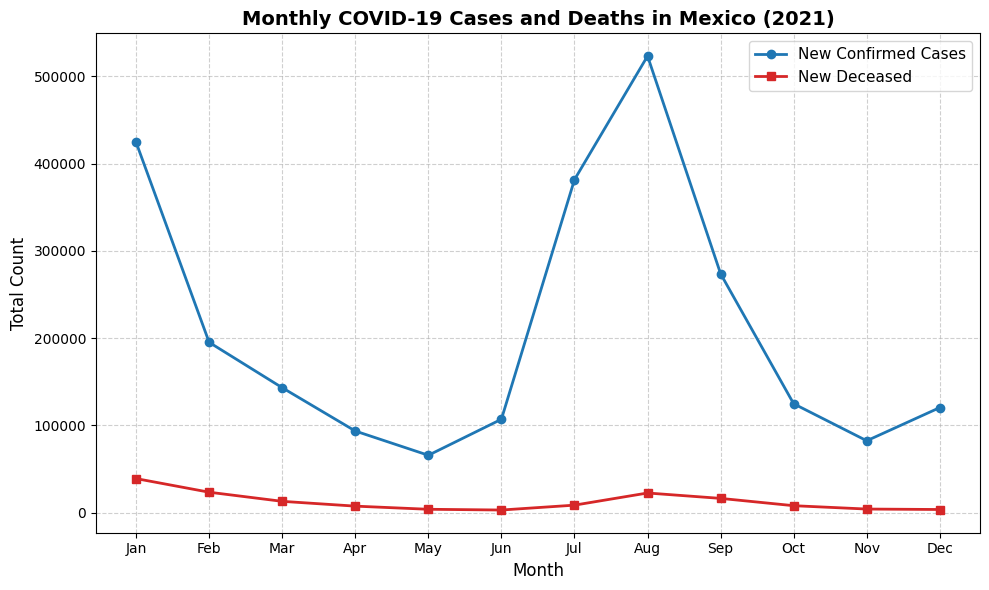

In [6]:
import matplotlib.pyplot as plt

# 1. Prepare for Aggregation: Extract month from date
mexico_covid_df['month'] = mexico_covid_df['date'].apply(lambda dt: dt.month)

# 2. Aggregate by Month: Group by month and sum new_confirmed and new_deceased
monthly_covid = mexico_covid_df.groupby('month')[['new_confirmed', 'new_deceased']].sum().reset_index()

# 3 & 4. Plot and Customize the Results
plt.figure(figsize=(10, 6))

plt.plot(monthly_covid['month'], monthly_covid['new_confirmed'], marker='o', linewidth=2, label='New Confirmed Cases', color='tab:blue')
plt.plot(monthly_covid['month'], monthly_covid['new_deceased'], marker='s', linewidth=2, label='New Deceased', color='tab:red')

plt.title('Monthly COVID-19 Cases and Deaths in Mexico (2021)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Count', fontsize=12)

# Set x-axis tick marks for all 12 months
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()